# 🏠 House Price Prediction 

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [2]:
df = pd.read_csv("House_Price_Prediction_Dataset.csv")
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


## 3. Data Exploration

In [3]:
df.shape

(2000, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [5]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


## 4. Visualization

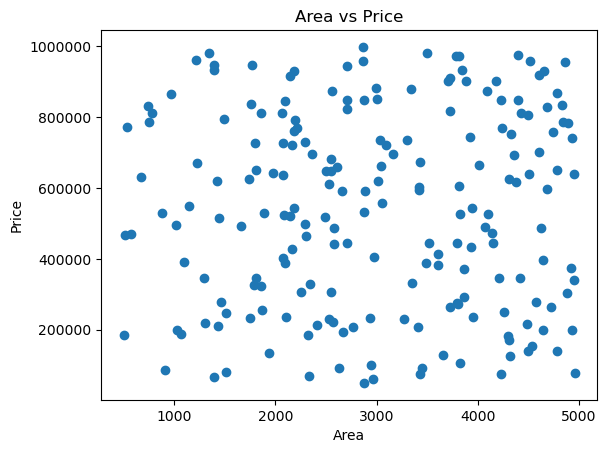

In [7]:
df_sample = df.sample(200)
plt.scatter(df_sample["Area"], df_sample["Price"],)
plt.ticklabel_format(style='plain')
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

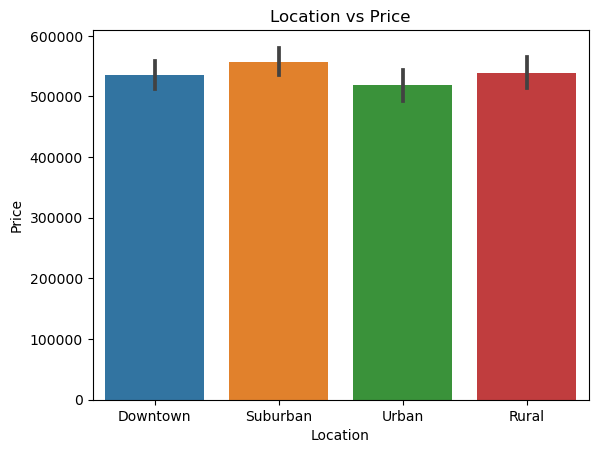

In [10]:
sns.barplot(x="Location", y="Price", data=df,estimator="mean")
plt.title("Location vs Price")
plt.show()

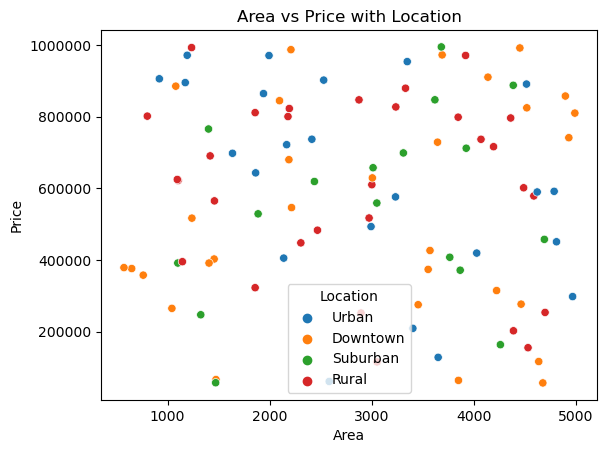

In [13]:
df_sample = df.sample(100)
sns.scatterplot(x="Area", y="Price", hue="Location", data=df_sample)
plt.ticklabel_format(style='plain')
plt.title("Area vs Price with Location")
plt.show()

## 5. Data Preprocessing

In [14]:
df.drop("Id", axis=1, inplace=True)
df = pd.get_dummies(df, drop_first=True)

## 6. Feature Selection

In [15]:
X = df.drop("Price", axis=1)
y = df["Price"]

## 7. Train Test Split

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 8. Linear Regression

In [23]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

print("Linear MAE:", lr_mae)
print("Linear RMSE:", lr_rmse)

Linear MAE: 243241.97758826384
Linear RMSE: 279859.72583784326


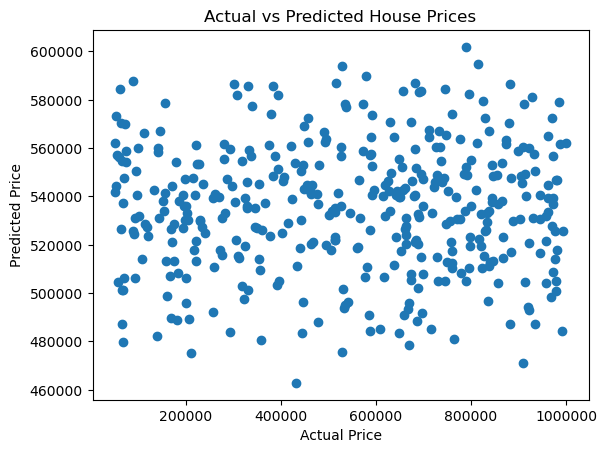

In [27]:
import matplotlib.pyplot as plt

plt.scatter(y_test, lr_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.ticklabel_format(style='plain')
plt.show()

In [33]:
comparsion=pd.DataFrame({
    "Actual Price":y_test,
    "Predicted Price":lr_pred
})
comparsion["error"]=comparsion["Actual Price"]-comparsion["Predicted Price"]
comparsion.head(5)

,Actual Price,Predicted Price,error
1860,514764,521988.221898,-7224.221898
353,694256,549119.311967,145136.688033
1333,66375,487101.222356,-420726.222356
905,650243,539752.743993,110490.256007
1289,223285,553242.248725,-329957.248725


### Insight

Most predictions are close to actual values, showing that the model has learned the underlying patterns well. However, some larger errors indicate variability in housing data.

## 9. Gradient Boosting

In [19]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.02, max_depth=2)
gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

In [20]:
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))

print("GB MAE:", gb_mae)
print("GB RMSE:", gb_rmse)

GB MAE: 243714.46058849245
GB RMSE: 280380.0852816679


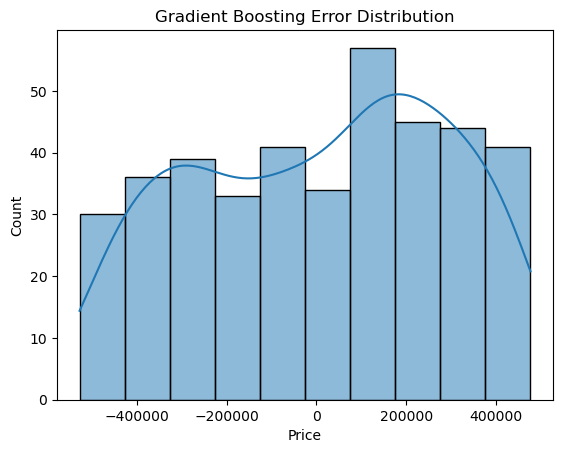

In [34]:
errors = y_test - gb_pred
sns.histplot(errors, kde=True)
plt.title("Gradient Boosting Error Distribution")
plt.show()

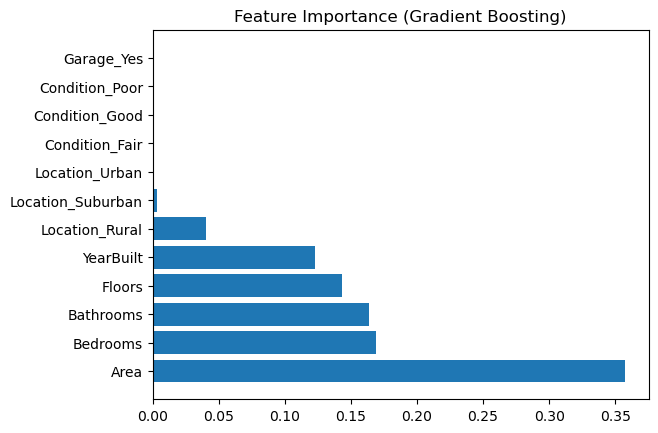

In [45]:
importance = pd.Series(gb_model.feature_importances_, index=X.columns)
k=importance.sort_values(ascending=False)
plt.barh(features,k)
plt.title("Feature Importance (Gradient Boosting)")
plt.show()

### Feature importance shows that Area is the most influential factor in the model. However, Location impact is distributed across multiple encoded features, which reduces its individual importance score.

## 10. Comparison

In [21]:
print("Linear MAE:", lr_mae)
print("Gradient Boosting MAE:", gb_mae)

Linear MAE: 243241.97758826384
Gradient Boosting MAE: 243714.46058849245


### both have almost same scores  

## 11. Conclusion



In this project, we built machine learning models to predict house prices using features such as area, bedrooms, bathrooms, location, and condition.

### 📊 Key Findings:
-  Area is the most influential factor in the model. However, Location impact is distributed across multiple encoded features, which reduces its individual importance score. -

### Comparison
- Both Linear Regression and Gradient Boosting models were applied
- Both models performed similarly with no significant improvement from the complex model

### 🧠 Final Insight:
This indicates that the dataset has mostly linear relationships, and a simple Linear Regression model is sufficient for this prediction task.

### 🚀 Overall:
The model successfully captures the main patterns in the data and provides reasonably accurate price predictions. 
